# 03 — Preprocessing Tests (No Face Detection/Cropping)

This notebook mirrors Notebook 02 preprocessing tests but intentionally skips face detection and face cropping.

Validated steps:
- Load metadata from Notebook 01 outputs
- Resize to 224×224
- Normalize using ImageNet mean/std
- Apply augmentations:
  - Horizontal flip
  - Random brightness/contrast
  - Mild rotation (±10°)
  - Light random crop/zoom
- Visualize preprocessing outputs on a small sample

In [5]:
# Bootstrap dependencies for this notebook kernel (safe to re-run)
%pip install -q numpy pandas pillow matplotlib opencv-python-headless albumentations

Note: you may need to restart the kernel to use updated packages.


In [6]:
from __future__ import annotations

import random
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TARGET_SIZE = (224, 224)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "dataset").exists() and (candidate / "docs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_ROOT = PROJECT_ROOT / "dataset" / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed root: {PROCESSED_ROOT}")
print(f"Target size: {TARGET_SIZE}")

Project root: /home/chicocaine/artificial-intelligence/age-gender-cnn
Processed root: /home/chicocaine/artificial-intelligence/age-gender-cnn/dataset/processed
Target size: (224, 224)


In [7]:
metadata_candidates = sorted(PROCESSED_ROOT.glob("utkface_metadata_*.csv"))
if not metadata_candidates:
    raise FileNotFoundError("No metadata CSV found in dataset/processed. Run notebook 01 first.")

metadata_path = metadata_candidates[-1]
metadata_df = pd.read_csv(metadata_path)

required_cols = {"path", "age", "gender"}
missing = required_cols - set(metadata_df.columns)
if missing:
    raise ValueError(f"Metadata file is missing required columns: {missing}")

metadata_df = metadata_df.dropna(subset=["path", "age", "gender"]).reset_index(drop=True)
metadata_df["path"] = metadata_df["path"].astype(str)

sample_n = 24
sample_df = metadata_df.sample(n=min(sample_n, len(metadata_df)), random_state=SEED).reset_index(drop=True)

print(f"Using metadata: {metadata_path.name}")
print(f"Rows available: {len(metadata_df):,}")
print(f"Sample size: {len(sample_df)}")
sample_df[["path", "age", "gender"]].head()

Using metadata: utkface_metadata_20260221T092508Z.csv
Rows available: 66,974
Sample size: 24


,path,age,gender
0,/home/chicocaine/artificial-intelligence/age-g...,21.0,1.0
1,/home/chicocaine/artificial-intelligence/age-g...,18.0,1.0
2,/home/chicocaine/artificial-intelligence/age-g...,65.0,0.0
3,/home/chicocaine/artificial-intelligence/age-g...,48.0,0.0
4,/home/chicocaine/artificial-intelligence/age-g...,42.0,1.0


In [8]:
def read_rgb(path: str) -> np.ndarray:
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB"), dtype=np.uint8)


def resize_image(rgb_img: np.ndarray, target_size: Tuple[int, int] = TARGET_SIZE) -> np.ndarray:
    return cv2.resize(rgb_img, target_size, interpolation=cv2.INTER_AREA)


def normalize_imagenet(rgb_img: np.ndarray) -> np.ndarray:
    arr = rgb_img.astype(np.float32) / 255.0
    return (arr - IMAGENET_MEAN) / IMAGENET_STD


def denormalize_imagenet(norm_img: np.ndarray) -> np.ndarray:
    arr = (norm_img * IMAGENET_STD + IMAGENET_MEAN).clip(0.0, 1.0)
    return (arr * 255.0).astype(np.uint8)


augmenter = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
        A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.RandomResizedCrop(size=TARGET_SIZE, scale=(0.9, 1.0), ratio=(0.95, 1.05), p=0.6),
    ]
)

preprocessed_samples = []
for _, row in sample_df.iterrows():
    path = row["path"]
    try:
        original_rgb = read_rgb(path)
        resized_rgb = resize_image(original_rgb, TARGET_SIZE)
        normalized = normalize_imagenet(resized_rgb)
        augmented = augmenter(image=resized_rgb)["image"]

        preprocessed_samples.append(
            {
                "path": path,
                "age": float(row["age"]),
                "gender": int(row["gender"]),
                "original_rgb": original_rgb,
                "resized_rgb": resized_rgb,
                "normalized": normalized,
                "augmented_rgb": augmented,
            }
        )
    except Exception as exc:
        preprocessed_samples.append({"path": path, "error": str(exc)})

successful = [x for x in preprocessed_samples if "error" not in x]
failed = [x for x in preprocessed_samples if "error" in x]

print(f"Preprocessed samples: {len(preprocessed_samples)}")
print(f"Successful: {len(successful)} | Failed: {len(failed)}")
if failed:
    pd.DataFrame(failed).head()

Preprocessed samples: 24
Successful: 24 | Failed: 0


Normalized tensor stats:
  shape: (24, 224, 224, 3)
  min: -2.1179, max: 2.6400
  mean (global): 0.1610, std (global): 1.0731


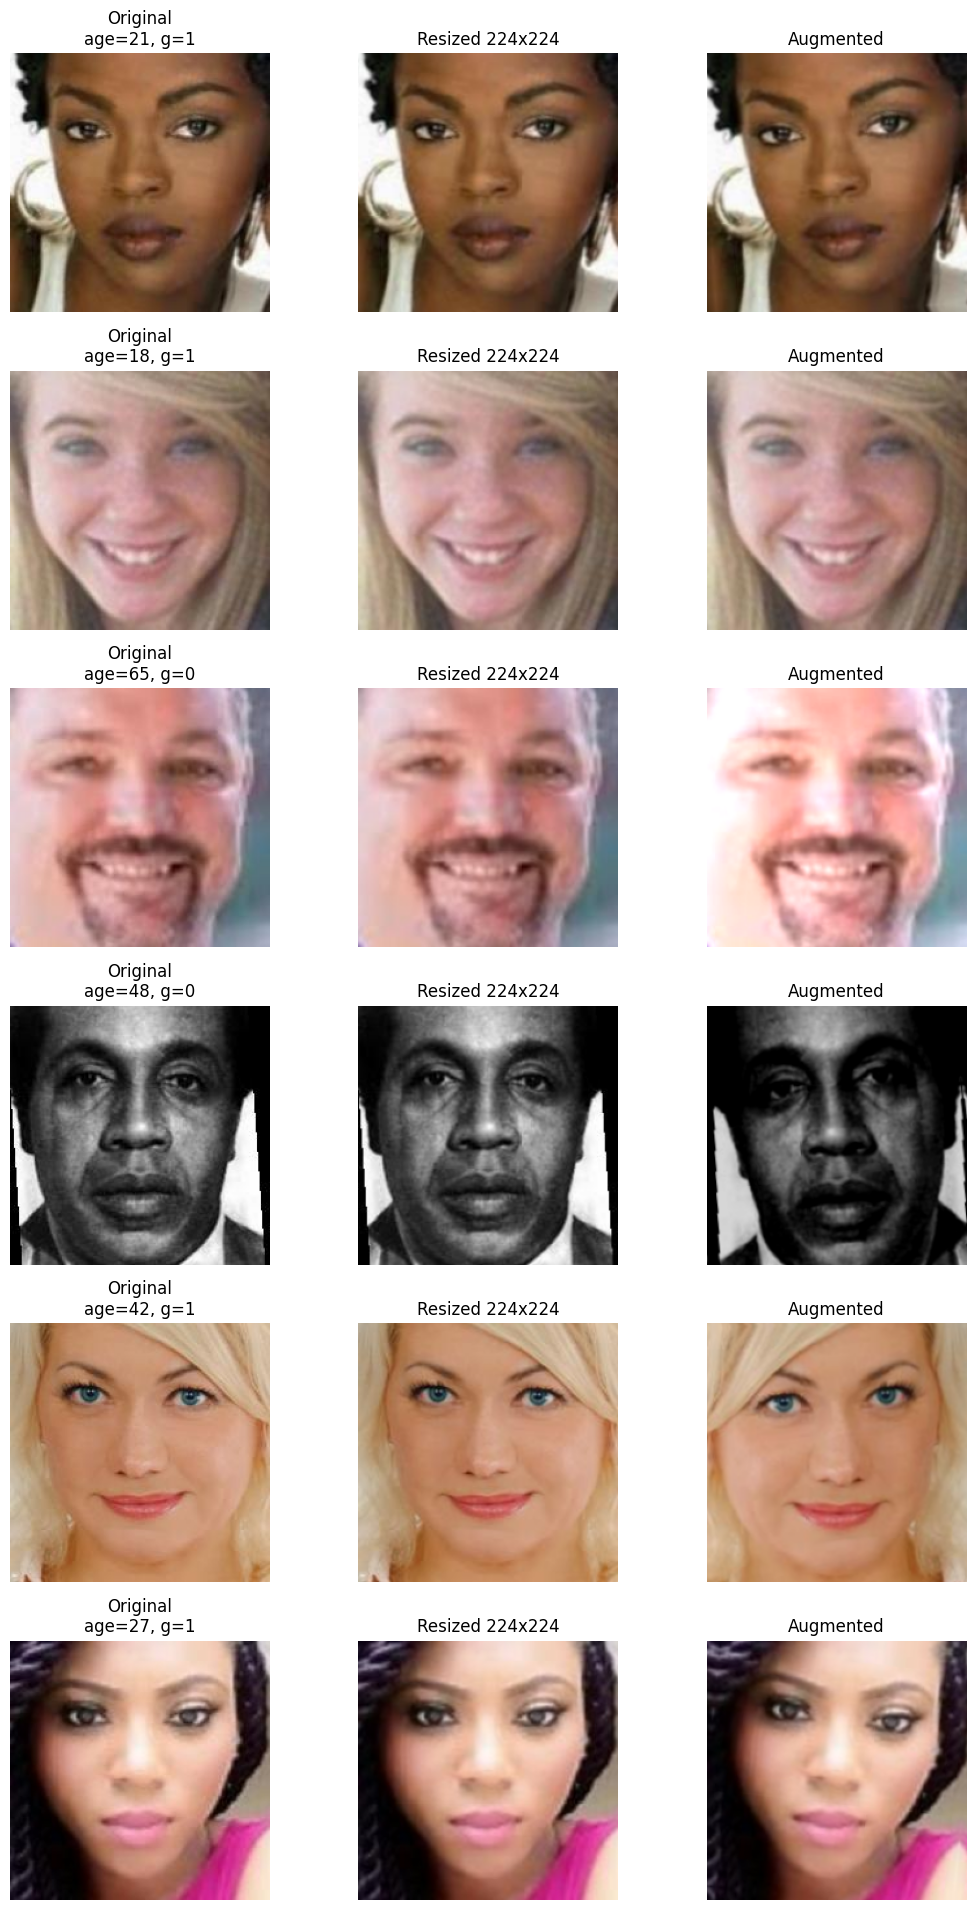

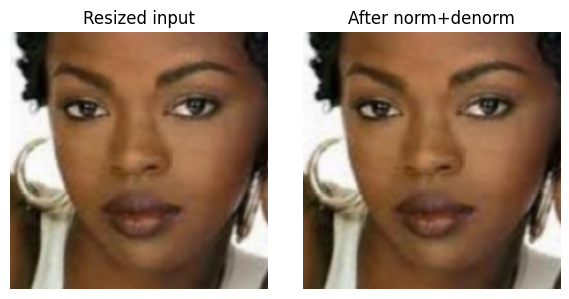

In [9]:
valid_samples = [x for x in preprocessed_samples if "error" not in x]
if not valid_samples:
    raise RuntimeError("No valid preprocessed samples available for visualization.")

norm_stack = np.stack([s["normalized"] for s in valid_samples], axis=0)
print("Normalized tensor stats:")
print(f"  shape: {norm_stack.shape}")
print(f"  min: {norm_stack.min():.4f}, max: {norm_stack.max():.4f}")
print(f"  mean (global): {norm_stack.mean():.4f}, std (global): {norm_stack.std():.4f}")

rows = min(6, len(valid_samples))
fig, axes = plt.subplots(rows, 3, figsize=(11, rows * 3.2))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(rows):
    item = valid_samples[i]
    axes[i, 0].imshow(item["original_rgb"])
    axes[i, 0].set_title(f"Original\nage={item['age']:.0f}, g={item['gender']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(item["resized_rgb"])
    axes[i, 1].set_title(f"Resized {TARGET_SIZE[0]}x{TARGET_SIZE[1]}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(item["augmented_rgb"])
    axes[i, 2].set_title("Augmented")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

first = valid_samples[0]
denorm_preview = denormalize_imagenet(first["normalized"])

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(first["resized_rgb"])
ax[0].set_title("Resized input")
ax[0].axis("off")
ax[1].imshow(denorm_preview)
ax[1].set_title("After norm+denorm")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Notes

- This notebook intentionally skips face detection/cropping.
- Use this variant when inputs are already face-aligned/cropped.
- Keep Notebook 02 for detector benchmarking and crop quality tests.

## Checklist Mapping

Completed in this notebook:
- Resize to target resolution (224×224)
- ImageNet normalization check
- Data augmentation checks:
  - Horizontal flip
  - Random brightness/contrast
  - Mild rotation (±10°)
  - Light random crop/zoom
- Small sample visualization for preprocessing validation

Scope note:
- This notebook intentionally skips face detection/cropping and is intended for already face-aligned or pre-cropped inputs.
- Use Notebook 02 for detector benchmarking and face-cropping evaluation.